
# Requirements:
# 1. Dataset Card
# 2. Load + Inspect Dataset
# 3. Missing / Duplicate / Corrupt Data
# 4. Target/Class Distribution + Plot
# 5. Train / Validation / Test Split
# 6. 3 Important Data Findings
# 7. Feature Distribution + Correlation + Outliers
# 8. 33 Attack Types + Grouping Decision

In [ ]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [21]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

In [22]:
# File paths

train_file = "CICIOT23/train/train.csv"
val_file = "CICIOT23/validation/validation.csv"
test_file = "CICIOT23/test/test.csv" 

In [61]:
# 2. LOAD + INSPECT DATASET

# CHECK FILES


print("\nChecking dataset files...")

for file_path in [train_file, val_file, test_file]:

    if os.path.exists(file_path):
        print("Found:", file_path)

    else:
        raise FileNotFoundError(
            f"\nFile not found: {file_path}\n"
            "Please check the file path."
        )





Checking dataset files...
Found: CICIOT23/train/train.csv
Found: CICIOT23/validation/validation.csv
Found: CICIOT23/test/test.csv


In [ ]:

# LOAD DATASETS

print("\nLoading training dataset...")
train_df = pd.read_csv(train_file)

print("Loading validation dataset...")
val_df = pd.read_csv(val_file)

print("Loading test dataset...")
test_df = pd.read_csv(test_file)

print("\nAll datasets loaded successfully!")



Loading training dataset...
Loading validation dataset...
Loading test dataset...

All datasets loaded successfully!


In [26]:
# ------------------------------------------------------------
# ORIGINAL DATASET SHAPES
# ------------------------------------------------------------

print("\nOriginal dataset shapes:")

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)





Original dataset shapes:
Train      : (5491971, 47)
Validation : (1176851, 47)
Test       : (1176851, 47)


In [27]:
# ------------------------------------------------------------
# COMBINE DATA FOR OVERALL EDA
# ------------------------------------------------------------

df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print("\nCombined EDA dataset shape:")
print(df.shape)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


# ------------------------------------------------------------
# FIRST 5 ROWS
# ------------------------------------------------------------

print("\nFirst 5 rows:")
display(df.head())


# ------------------------------------------------------------
# RANDOM 5 SAMPLES
# ------------------------------------------------------------

print("\n5 Random Samples:")

display(
    df.sample(
        min(5, len(df)),
        random_state=RANDOM_STATE
    )
)


# ------------------------------------------------------------
# DATA TYPES
# ------------------------------------------------------------

print("\nData Types:")
print(df.dtypes)


# ------------------------------------------------------------
# DATAFRAME INFORMATION
# ------------------------------------------------------------

print("\nDataFrame Information:")
df.info()


# ------------------------------------------------------------
# UNIQUE VALUES
# ------------------------------------------------------------

print("\nUnique values per column:")

unique_values = df.nunique().sort_values()

display(
    unique_values.to_frame("Unique_Values")
)



Combined EDA dataset shape:
(7845673, 47)

Number of rows: 7845673
Number of columns: 47

First 5 rows:


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,9627.00,374.0,1457.00,883.202217,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.00,54.000000,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.99,0.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,572.51,54.0,59.51,54.753345,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,6216.00,592.0,592.00,592.000000,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.00,54.000000,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood



5 Random Samples:


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
3833339,0.094940,37695.00,17.00,64.00,7768.354078,7768.354078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,525.00,50.00,50.00,50.000000,0.000000,50.00,8.312374e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
209578,0.000000,0.00,1.00,64.00,1.855244,1.855244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,441.00,42.00,42.00,42.000000,0.000000,42.00,8.312856e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
5141010,0.000000,54.00,6.00,64.00,0.838266,0.838266,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.00,54.00,54.000000,0.000000,54.00,8.309320e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2694567,0.103537,19469.50,16.66,62.72,5229.184035,5229.184035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,526.50,50.00,50.80,50.091213,0.253040,50.20,8.310644e+07,9.5,10.009121,0.358828,0.809323,0.08,141.55,DDoS-UDP_Flood
749870,0.706576,76.84,6.27,97.74,0.740835,0.740835,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.15,0.18,0.0,0.28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,583.36,54.04,65.81,55.258893,3.003379,57.06,8.298561e+07,9.5,10.503279,3.808234,32.346203,0.31,141.55,DoS-SYN_Flood



Data Types:
flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          float64
syn_count          float64
fin_count          float64
urg_count          float64
rst_count          float64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IPv                float64
LLC                float64
Tot sum            float64
Min                float64
Max                float64
AVG            

,Unique_Values
IRC,1
Telnet,1
fin_flag_number,2
psh_flag_number,2
ack_flag_number,2
syn_flag_number,2
cwr_flag_number,2
ece_flag_number,2
DNS,2
SSH,2


In [ ]:

# 3. MISSING / DUPLICATE / CORRUPT DATA

# MISSING VALUES

missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print("\nMissing values:")

if len(missing_values) == 0:
    print("No missing values found.")

else:
    display(
        missing_values.to_frame("Missing_Count")
    )

print(
    "\nTotal missing values:",
    df.isnull().sum().sum()
)




Missing values:
No missing values found.

Total missing values: 0


In [29]:
# ------------------------------------------------------------
# DUPLICATES
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

print("\nDuplicate rows:", duplicate_count)

duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print(
    "Duplicate percentage:",
    round(duplicate_percentage, 4),
    "%"
)


# ------------------------------------------------------------
# INFINITE VALUES
# ------------------------------------------------------------

numeric_columns = df.select_dtypes(
    include=np.number
).columns

if len(numeric_columns) > 0:

    infinite_counts = np.isinf(
        df[numeric_columns]
    ).sum()

    infinite_counts = infinite_counts[
        infinite_counts > 0
    ]

    print("\nInfinite values:")

    if len(infinite_counts) == 0:
        print("No infinite values found.")

    else:
        display(
            infinite_counts.to_frame(
                "Infinite_Count"
            )
        )

else:
    print("\nNo numeric columns found.")





Duplicate rows: 275259
Duplicate percentage: 3.5084 %

Infinite values:
No infinite values found.


In [30]:

# Clean each dataset
for data in [train_df, val_df, test_df]:
    for col in data.select_dtypes(include=np.number):
        data.loc[np.isinf(data[col]), col] = np.nan
    data.drop_duplicates(inplace=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (5357406, 47)
Validation: (1170554, 47)
Test: (1170467, 47)


In [33]:
# Remove exact duplicates from each dataset

for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    before_duplicates = len(data)

    data.drop_duplicates(inplace=True)

    after_duplicates = len(data)

    print(f"\n{name} rows before duplicate removal:", before_duplicates)
    print(f"{name} rows after duplicate removal:", after_duplicates)
    print(f"{name} duplicates removed:", before_duplicates - after_duplicates)


Train rows before duplicate removal: 5357406
Train rows after duplicate removal: 5357406
Train duplicates removed: 0

Validation rows before duplicate removal: 1170554
Validation rows after duplicate removal: 1170554
Validation duplicates removed: 0

Test rows before duplicate removal: 1170467
Test rows after duplicate removal: 1170467
Test duplicates removed: 0


In [36]:


# 4. TARGET / CLASS DISTRIBUTION


# AUTOMATIC TARGET DETECTION


possible_targets = [
    "label", "Label", "LABEL",
    "class", "Class", "CLASS",
    "attack", "Attack",
    "attack_class", "Attack_Class",
    "category", "Category"
]

target_col = next(
    (col for col in possible_targets if col in train_df.columns),
    None
)

if target_col is None:
    raise ValueError(
        "Target column not found. Available columns:\n"
        + str(train_df.columns.tolist())
    )

print("\nDetected target column:", target_col)




Detected target column: label


In [37]:
# ------------------------------------------------------------
# REMOVE MISSING TARGETS
# ------------------------------------------------------------

for data in [train_df, val_df, test_df]:
    data.dropna(subset=[target_col], inplace=True)


# CLASS DISTRIBUTION - TRAINING SET


class_counts = train_df[target_col].value_counts()

class_percentage = (
    train_df[target_col]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

print("\nClass distribution:")
display(class_counts.to_frame("Count"))

print("\nClass percentages:")
display(class_percentage.to_frame("Percentage"))





Class distribution:


,Count
label,
DDoS-ICMP_Flood,827284
DDoS-UDP_Flood,622030
DDoS-TCP_Flood,515528
DDoS-PSHACK_Flood,469502
DDoS-SYN_Flood,466978
DDoS-RSTFINFlood,463757
DDoS-SynonymousIP_Flood,411697
DoS-UDP_Flood,380860
DoS-TCP_Flood,306329



Class percentages:


,Percentage
label,
DDoS-ICMP_Flood,15.442
DDoS-UDP_Flood,11.611
DDoS-TCP_Flood,9.623
DDoS-PSHACK_Flood,8.764
DDoS-SYN_Flood,8.716
DDoS-RSTFINFlood,8.656
DDoS-SynonymousIP_Flood,7.685
DoS-UDP_Flood,7.109
DoS-TCP_Flood,5.718


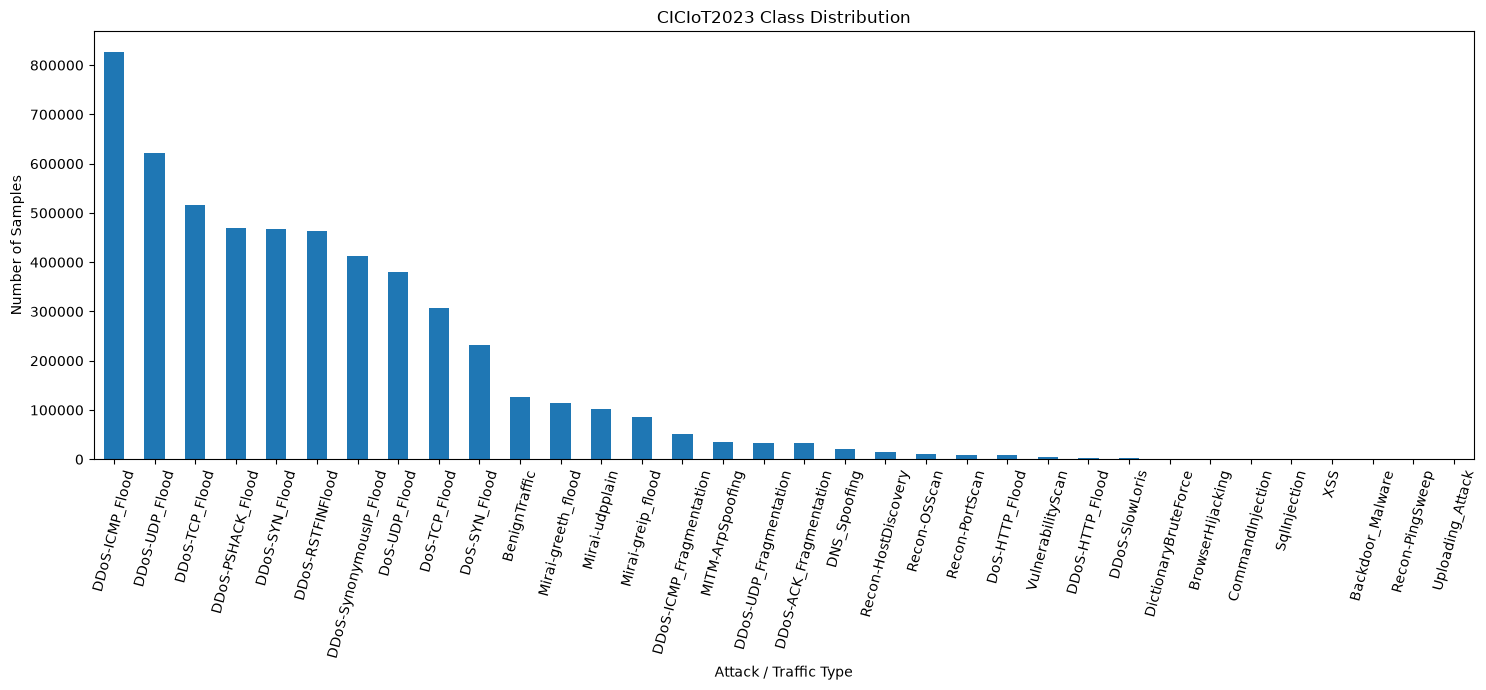

In [38]:
# CLASS DISTRIBUTION PLOT
# ------------------------------------------------------------

plt.figure(figsize=(15, 7))
class_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("CICIoT2023 Class Distribution")
plt.xlabel("Attack / Traffic Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()



In [39]:
# ------------------------------------------------------------
# IMBALANCE RATIO
# ------------------------------------------------------------

largest_class = class_counts.idxmax()
smallest_class = class_counts.idxmin()

largest_count = class_counts.max()
smallest_count = class_counts.min()

print("\nLargest class:", largest_class)
print("Largest class count:", largest_count)

print("\nSmallest class:", smallest_class)
print("Smallest class count:", smallest_count)

if smallest_count > 0:
    print(
        "\nImbalance ratio:",
        round(largest_count / smallest_count, 2)
    )




Largest class: DDoS-ICMP_Flood
Largest class count: 827284

Smallest class: Uploading_Attack
Smallest class count: 139

Imbalance ratio: 5951.68


In [40]:
# ============================================================
# 5. TRAIN / VALIDATION / TEST
# ============================================================

print("\n" + "=" * 70)
print("5. TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

print("\nUsing the original CICIoT2023 train/validation/test split.")



5. TRAIN / VALIDATION / TEST SPLIT

Using the original CICIoT2023 train/validation/test split.


In [41]:
# ------------------------------------------------------------
# FEATURES + TARGET
# ------------------------------------------------------------

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]



In [42]:
# ------------------------------------------------------------
# NUMERIC FEATURES
# ------------------------------------------------------------

X_train_numeric = X_train.select_dtypes(include=np.number)
X_val_numeric = X_val.select_dtypes(include=np.number)
X_test_numeric = X_test.select_dtypes(include=np.number)

print("\nTrain shape:", X_train_numeric.shape)
print("Validation shape:", X_val_numeric.shape)
print("Test shape:", X_test_numeric.shape)

print("\nTotal features:", X_train.shape[1])
print("Numeric features:", X_train_numeric.shape[1])
print("Non-numeric features:",
      X_train.shape[1] - X_train_numeric.shape[1])




Train shape: (5357406, 46)
Validation shape: (1170554, 46)
Test shape: (1170467, 46)

Total features: 46
Numeric features: 46
Non-numeric features: 0


In [43]:
# ------------------------------------------------------------
# CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\nTrain class distribution:")
display(y_train.value_counts(normalize=True).round(4))

print("\nValidation class distribution:")
display(y_val.value_counts(normalize=True).round(4))

print("\nTest class distribution:")
display(y_test.value_counts(normalize=True).round(4))



Train class distribution:


label
DDoS-ICMP_Flood            0.1544
DDoS-UDP_Flood             0.1161
DDoS-TCP_Flood             0.0962
DDoS-PSHACK_Flood          0.0876
DDoS-SYN_Flood             0.0872
DDoS-RSTFINFlood           0.0866
DDoS-SynonymousIP_Flood    0.0768
DoS-UDP_Flood              0.0711
DoS-TCP_Flood              0.0572
DoS-SYN_Flood              0.0433
BenignTraffic              0.0236
Mirai-greeth_flood         0.0212
Mirai-udpplain             0.0191
Mirai-greip_flood          0.0162
DDoS-ICMP_Fragmentation    0.0097
MITM-ArpSpoofing           0.0066
DDoS-UDP_Fragmentation     0.0062
DDoS-ACK_Fragmentation     0.0061
DNS_Spoofing               0.0039
Recon-HostDiscovery        0.0029
Recon-OSScan               0.0021
Recon-PortScan             0.0018
DoS-HTTP_Flood             0.0015
VulnerabilityScan          0.0008
DDoS-HTTP_Flood            0.0006
DDoS-SlowLoris             0.0005
DictionaryBruteForce       0.0003
BrowserHijacking           0.0001
CommandInjection           0.0001
SqlInjec


Validation class distribution:


label
DDoS-ICMP_Flood            0.1546
DDoS-UDP_Flood             0.1160
DDoS-TCP_Flood             0.0968
DDoS-PSHACK_Flood          0.0875
DDoS-SYN_Flood             0.0872
DDoS-RSTFINFlood           0.0863
DDoS-SynonymousIP_Flood    0.0772
DoS-UDP_Flood              0.0709
DoS-TCP_Flood              0.0570
DoS-SYN_Flood              0.0434
BenignTraffic              0.0234
Mirai-greeth_flood         0.0212
Mirai-udpplain             0.0190
Mirai-greip_flood          0.0160
DDoS-ICMP_Fragmentation    0.0097
MITM-ArpSpoofing           0.0066
DDoS-UDP_Fragmentation     0.0061
DDoS-ACK_Fragmentation     0.0061
DNS_Spoofing               0.0039
Recon-HostDiscovery        0.0030
Recon-OSScan               0.0021
Recon-PortScan             0.0018
DoS-HTTP_Flood             0.0016
VulnerabilityScan          0.0008
DDoS-HTTP_Flood            0.0006
DDoS-SlowLoris             0.0005
DictionaryBruteForce       0.0002
BrowserHijacking           0.0001
SqlInjection               0.0001
CommandI


Test class distribution:


label
DDoS-ICMP_Flood            0.1534
DDoS-UDP_Flood             0.1162
DDoS-TCP_Flood             0.0966
DDoS-PSHACK_Flood          0.0878
DDoS-SYN_Flood             0.0868
DDoS-RSTFINFlood           0.0865
DDoS-SynonymousIP_Flood    0.0769
DoS-UDP_Flood              0.0711
DoS-TCP_Flood              0.0575
DoS-SYN_Flood              0.0434
BenignTraffic              0.0236
Mirai-greeth_flood         0.0212
Mirai-udpplain             0.0192
Mirai-greip_flood          0.0164
DDoS-ICMP_Fragmentation    0.0097
MITM-ArpSpoofing           0.0067
DDoS-ACK_Fragmentation     0.0062
DDoS-UDP_Fragmentation     0.0061
DNS_Spoofing               0.0039
Recon-HostDiscovery        0.0028
Recon-OSScan               0.0021
Recon-PortScan             0.0018
DoS-HTTP_Flood             0.0015
VulnerabilityScan          0.0008
DDoS-HTTP_Flood            0.0006
DDoS-SlowLoris             0.0005
DictionaryBruteForce       0.0003
SqlInjection               0.0001
BrowserHijacking           0.0001
CommandI

In [46]:
# ============================================================
# 6. THREE IMPORTANT DATA FINDINGS
# ============================================================

# ------------------------------------------------------------
# FINDING 1 - CLASS IMBALANCE
# ------------------------------------------------------------

print("\nFINDING 1: CLASS IMBALANCE")

print(
    f"Largest class: {largest_class} "
    f"({largest_count:,} samples, "
    f"{class_percentage.loc[largest_class]:.2f}%)."
)

print(
    f"Smallest class: {smallest_class} "
    f"({smallest_count:,} samples, "
    f"{class_percentage.loc[smallest_class]:.2f}%)."
)





FINDING 1: CLASS IMBALANCE
Largest class: DDoS-ICMP_Flood (827,284 samples, 15.44%).
Smallest class: Uploading_Attack (139 samples, 0.00%).


In [47]:
# ------------------------------------------------------------
# FINDING 2 - HIGH CORRELATION
# ------------------------------------------------------------

print("\nFINDING 2: HIGHLY CORRELATED FEATURES")

# Correlation uses training data only
corr_matrix = X_train_numeric.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[
    high_corr_pairs > 0.90
]

if len(high_corr_pairs) == 0:
    print("No feature pairs with |correlation| > 0.90.")
else:
    display(high_corr_pairs.head(20))




FINDING 2: HIGHLY CORRELATED FEATURES


IPv              LLC                1.000000
Rate             Srate              1.000000
Std              Radius             0.999969
Number           Weight             0.999588
IAT              Weight             0.997349
                 Number             0.996038
fin_flag_number  ack_count          0.986093
                 rst_flag_number    0.975654
AVG              Magnitue           0.968309
rst_flag_number  ack_count          0.962245
Max              Std                0.952550
                 Radius             0.952528
AVG              Tot size           0.940260
Tot sum          AVG                0.934128
Tot size         Magnitue           0.928804
Tot sum          Magnitue           0.922420
dtype: float64

In [48]:
# ------------------------------------------------------------
# FINDING 3 - SKEWNESS
# ------------------------------------------------------------

print("\nFINDING 3: FEATURE SKEWNESS")

skewness = (
    X_train_numeric
    .skew()
    .abs()
    .sort_values(ascending=False)
)

display(skewness.head(15))



FINDING 3: FEATURE SKEWNESS


SMTP               2314.607094
cwr_flag_number    1336.338281
Drate              1057.078889
ece_flag_number     944.933066
DHCP                818.335582
flow_duration       167.114518
SSH                 150.023738
ARP                 123.532480
IPv                  95.437099
LLC                  95.437099
DNS                  87.342068
Covariance           53.399948
fin_count            31.500689
urg_count            24.167604
Srate                23.223004
dtype: float64

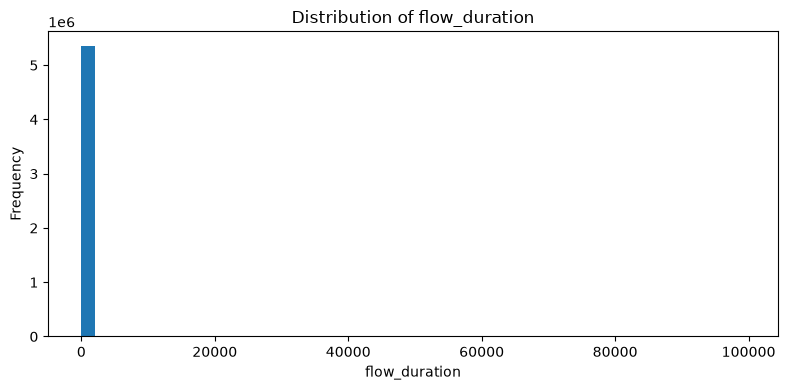

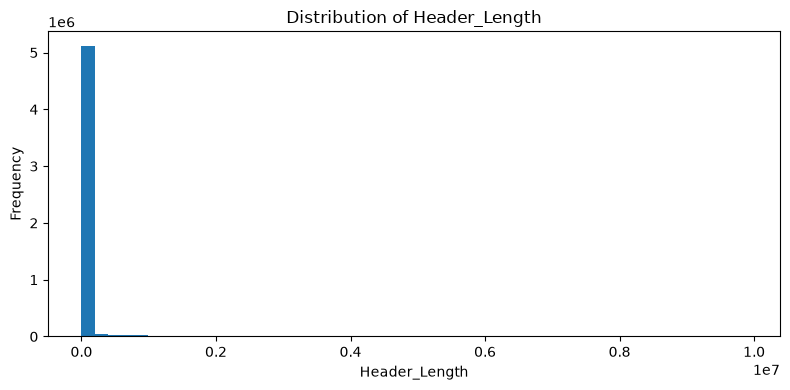

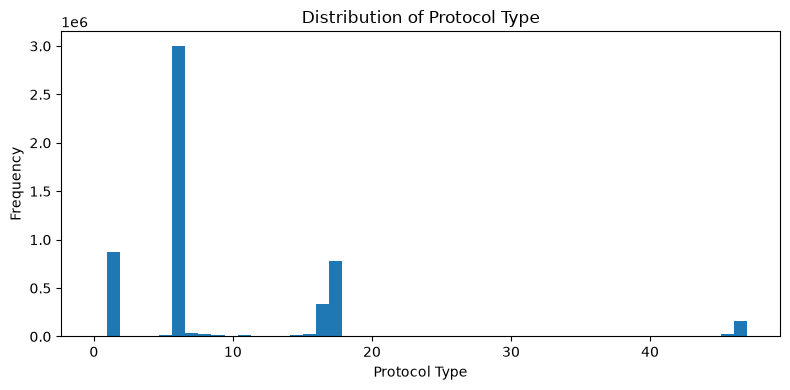

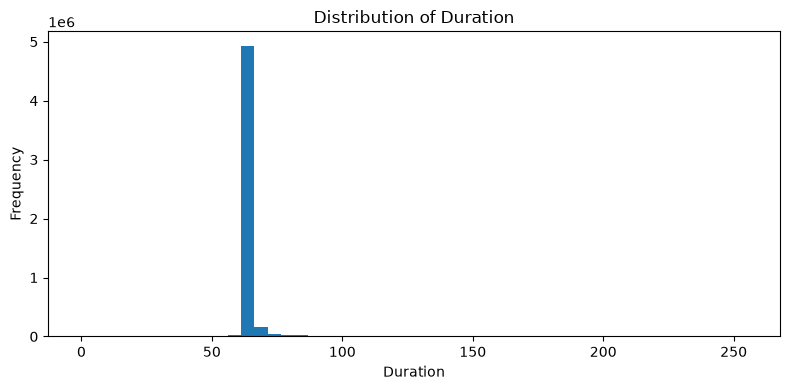

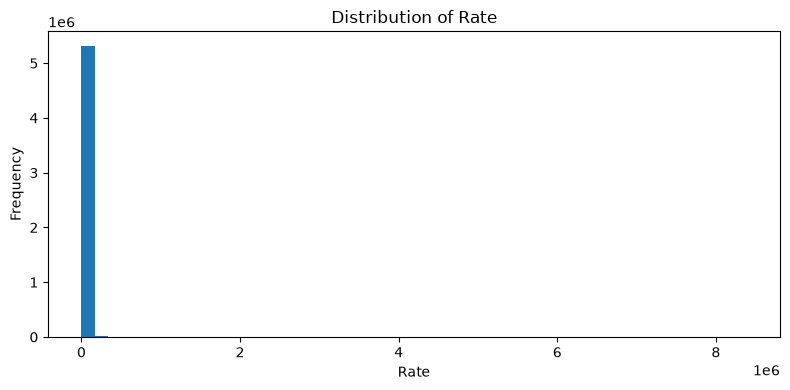

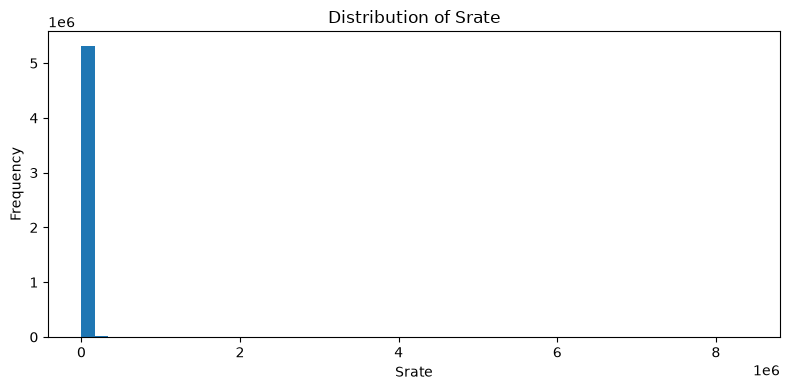

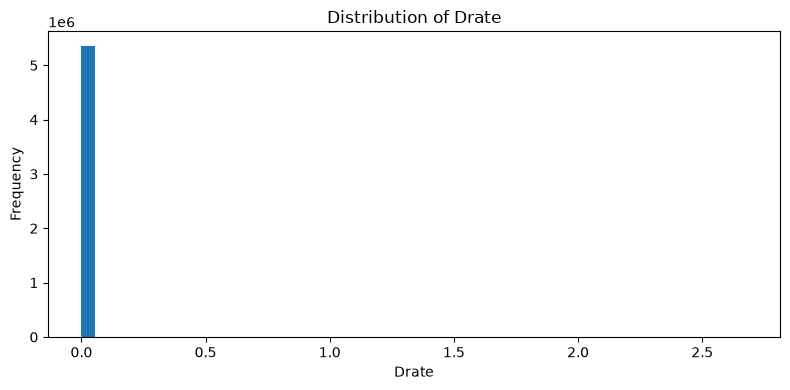

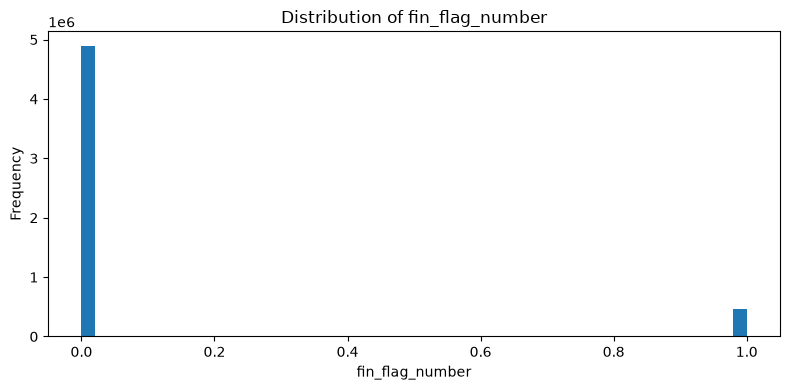

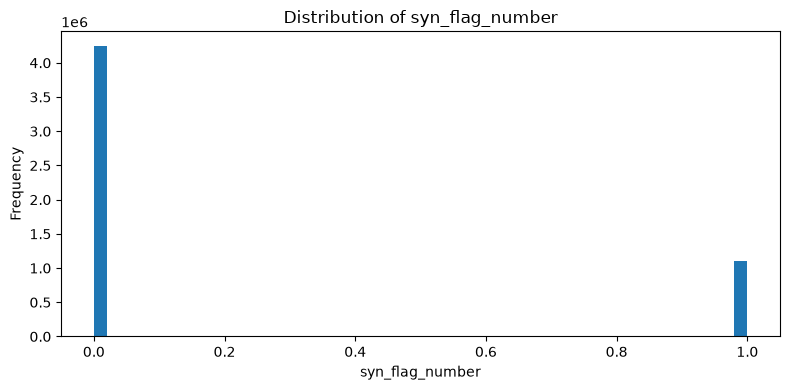

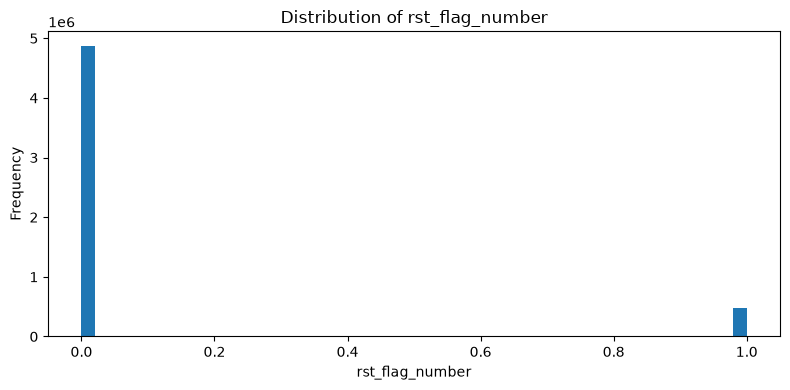

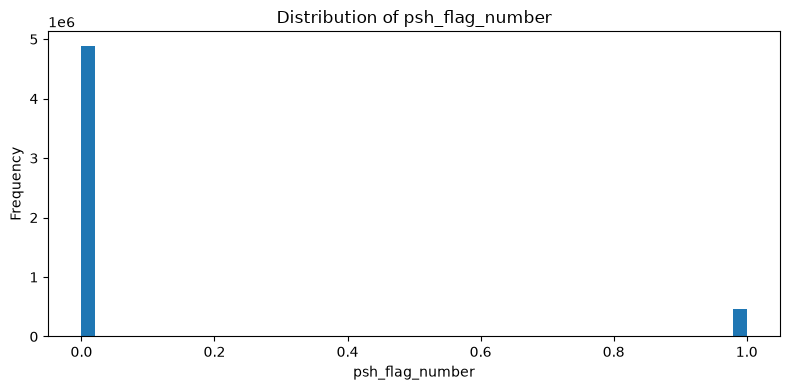

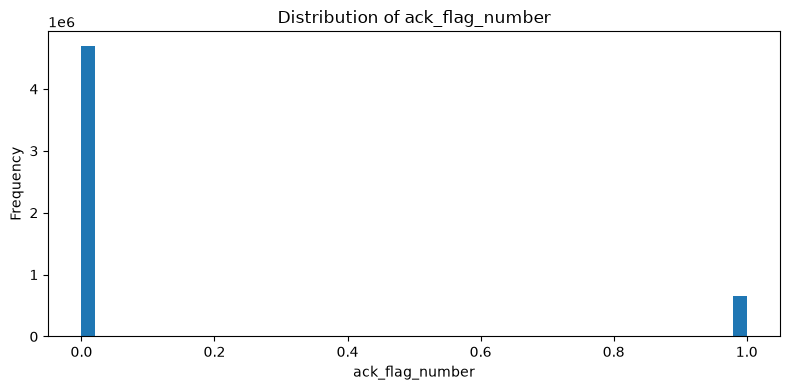

In [49]:
# ============================================================
# 7. FEATURE DISTRIBUTION + CORRELATION + OUTLIERS

# FEATURE DISTRIBUTIONS
# ------------------------------------------------------------

features_to_plot = list(X_train_numeric.columns[:12])

for feature in features_to_plot:

    plt.figure(figsize=(8, 4))

    plt.hist(
        X_train_numeric[feature].dropna(),
        bins=50
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()



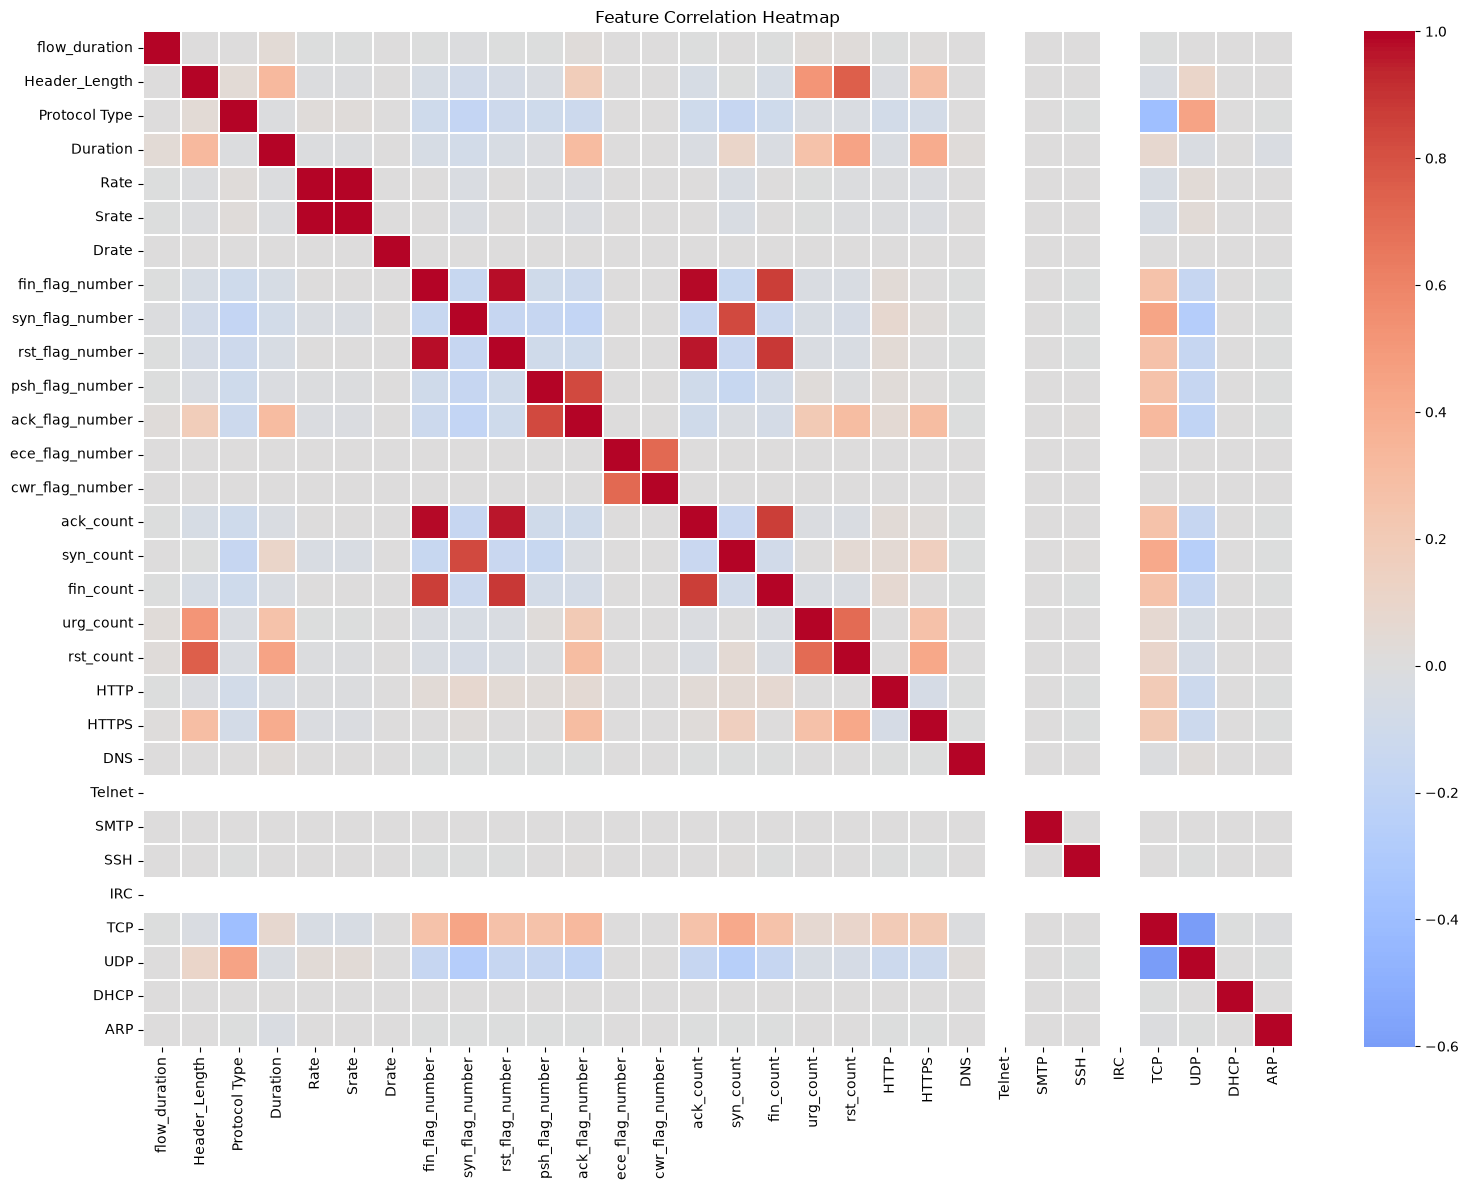

In [50]:
# ------------------------------------------------------------
# CORRELATION HEATMAP
# ------------------------------------------------------------

heatmap_features = list(X_train_numeric.columns[:30])

plt.figure(figsize=(16, 12))

corr = X_train_numeric[heatmap_features].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()



In [51]:
# ------------------------------------------------------------
# OUTLIER DETECTION
# ------------------------------------------------------------

outlier_summary = []

for col in X_train_numeric.columns:

    Q1 = X_train_numeric[col].quantile(0.25)
    Q3 = X_train_numeric[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (X_train_numeric[col] < lower) |
        (X_train_numeric[col] > upper)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Outlier_Count": count,
        "Outlier_Percentage":
            count / len(X_train_numeric) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    "Outlier_Percentage",
    ascending=False,
    inplace=True
)

print("\nTop 20 features with outliers:")
display(outlier_df.head(20))




Top 20 features with outliers:


,Feature,Outlier_Count,Outlier_Percentage
35,Max,1714073,31.994458
36,AVG,1649162,30.782845
38,Tot size,1648764,30.775416
33,Tot sum,1641037,30.631186
41,Magnitue,1640914,30.628890
34,Min,1539107,28.728586
3,Duration,1421903,26.540886
1,Header_Length,1316382,24.571257
15,syn_count,1282619,23.941045
43,Covariance,1210144,22.588245


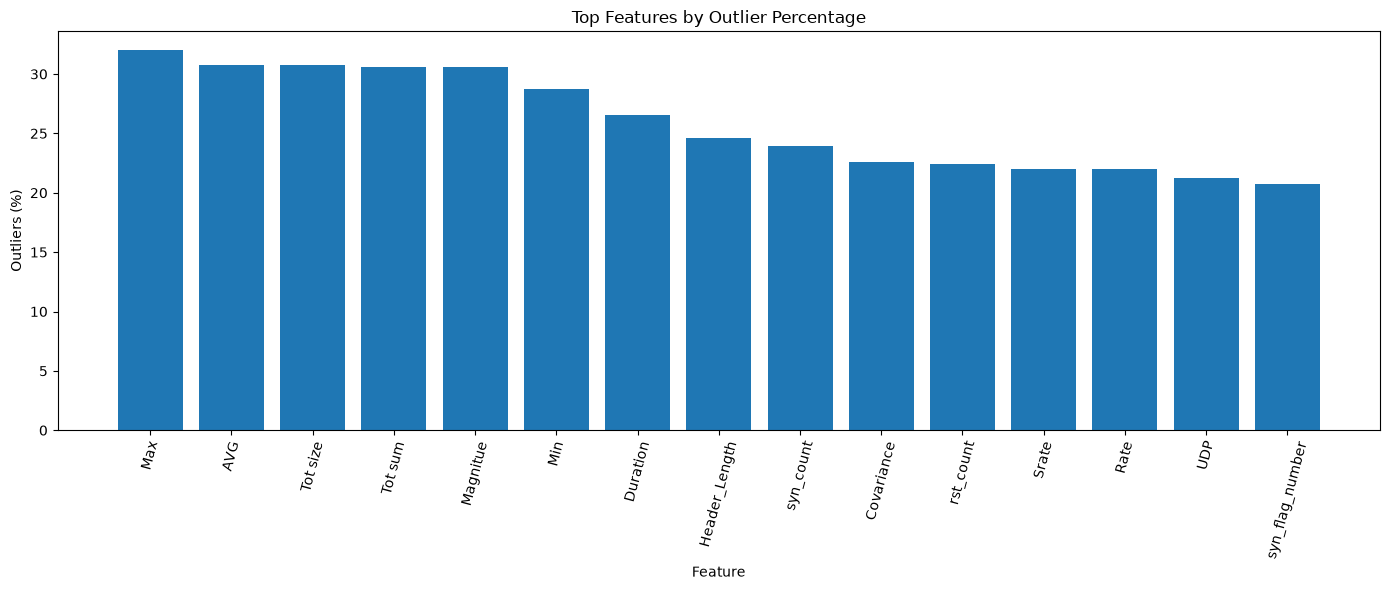

In [52]:
# ------------------------------------------------------------
# OUTLIER PLOT
# ------------------------------------------------------------

top_outliers = outlier_df.head(15)

plt.figure(figsize=(14, 6))

plt.bar(
    top_outliers["Feature"],
    top_outliers["Outlier_Percentage"]
)

plt.title("Top Features by Outlier Percentage")
plt.xlabel("Feature")
plt.ylabel("Outliers (%)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


In [53]:
# ============================================================
# 8. ATTACK TYPES + GROUPING


# ------------------------------------------------------------
# UNIQUE ATTACK TYPES
# ------------------------------------------------------------

attack_types = sorted(
    train_df[target_col].astype(str).unique()
)

print("\nNumber of unique labels:", len(attack_types))

print("\nAttack / Traffic Types:")

for i, attack in enumerate(attack_types, 1):
    print(f"{i:02d}. {attack}")




Number of unique labels: 34

Attack / Traffic Types:
01. Backdoor_Malware
02. BenignTraffic
03. BrowserHijacking
04. CommandInjection
05. DDoS-ACK_Fragmentation
06. DDoS-HTTP_Flood
07. DDoS-ICMP_Flood
08. DDoS-ICMP_Fragmentation
09. DDoS-PSHACK_Flood
10. DDoS-RSTFINFlood
11. DDoS-SYN_Flood
12. DDoS-SlowLoris
13. DDoS-SynonymousIP_Flood
14. DDoS-TCP_Flood
15. DDoS-UDP_Flood
16. DDoS-UDP_Fragmentation
17. DNS_Spoofing
18. DictionaryBruteForce
19. DoS-HTTP_Flood
20. DoS-SYN_Flood
21. DoS-TCP_Flood
22. DoS-UDP_Flood
23. MITM-ArpSpoofing
24. Mirai-greeth_flood
25. Mirai-greip_flood
26. Mirai-udpplain
27. Recon-HostDiscovery
28. Recon-OSScan
29. Recon-PingSweep
30. Recon-PortScan
31. SqlInjection
32. Uploading_Attack
33. VulnerabilityScan
34. XSS


In [54]:
# ------------------------------------------------------------
# ATTACK DISTRIBUTION
# ------------------------------------------------------------

attack_distribution = (
    train_df[target_col]
    .value_counts()
    .rename_axis("Attack_Type")
    .reset_index(name="Count")
)

display(attack_distribution)



,Attack_Type,Count
0,DDoS-ICMP_Flood,827284
1,DDoS-UDP_Flood,622030
2,DDoS-TCP_Flood,515528
3,DDoS-PSHACK_Flood,469502
4,DDoS-SYN_Flood,466978
5,DDoS-RSTFINFlood,463757
6,DDoS-SynonymousIP_Flood,411697
7,DoS-UDP_Flood,380860
8,DoS-TCP_Flood,306329
9,DoS-SYN_Flood,231748


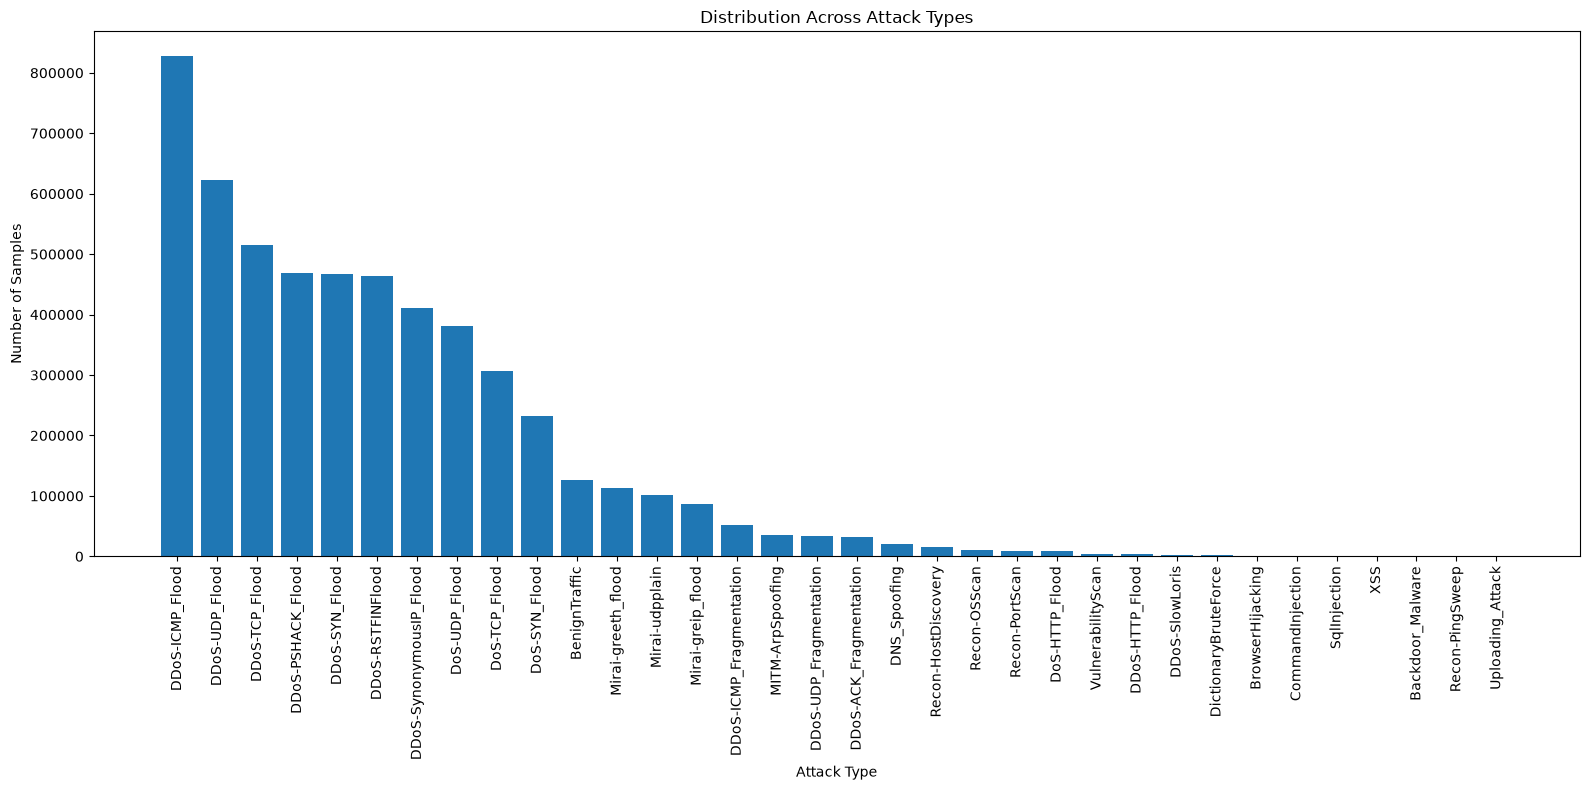

In [55]:
# ------------------------------------------------------------
# ATTACK PLOT
# ------------------------------------------------------------

plt.figure(figsize=(16, 8))

plt.bar(
    attack_distribution["Attack_Type"],
    attack_distribution["Count"]
)

plt.title("Distribution Across Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()




In [56]:
# ============================================================
# ATTACK FAMILY GROUPING
# ============================================================

def group_attack(label):

    label = str(label).lower().strip()

    if "benign" in label:
        return "Benign"

    if label.startswith("ddos"):
        return "DDoS"

    if label.startswith("dos"):
        return "DoS"

    if label.startswith("recon"):
        return "Recon"

    web_attacks = [
        "backdoor",
        "browserhijacking",
        "commandinjection",
        "sqlinjection",
        "uploading",
        "xss"
    ]

    if any(x in label for x in web_attacks):
        return "Web-based"

    if "brute" in label or "dictionary" in label:
        return "Brute Force"

    if "spoof" in label or "arp" in label:
        return "Spoofing"

    if "mirai" in label:
        return "Mirai"

    return "Other"




In [57]:
# ------------------------------------------------------------
# APPLY GROUPING TO EACH SPLIT
# ------------------------------------------------------------

train_df["attack_family"] = train_df[target_col].apply(group_attack)
val_df["attack_family"] = val_df[target_col].apply(group_attack)
test_df["attack_family"] = test_df[target_col].apply(group_attack)

# ------------------------------------------------------------
# GROUPED DISTRIBUTION
# ------------------------------------------------------------

grouped_counts = train_df["attack_family"].value_counts()

print("\nGrouped Attack Family Distribution:")
display(grouped_counts.to_frame("Count"))




Grouped Attack Family Distribution:


,Count
attack_family,
DDoS,3900616
DoS,927204
Mirai,302263
Benign,126395
Spoofing,56096
Recon,36287
Other,4289
Web-based,2768
Brute Force,1488


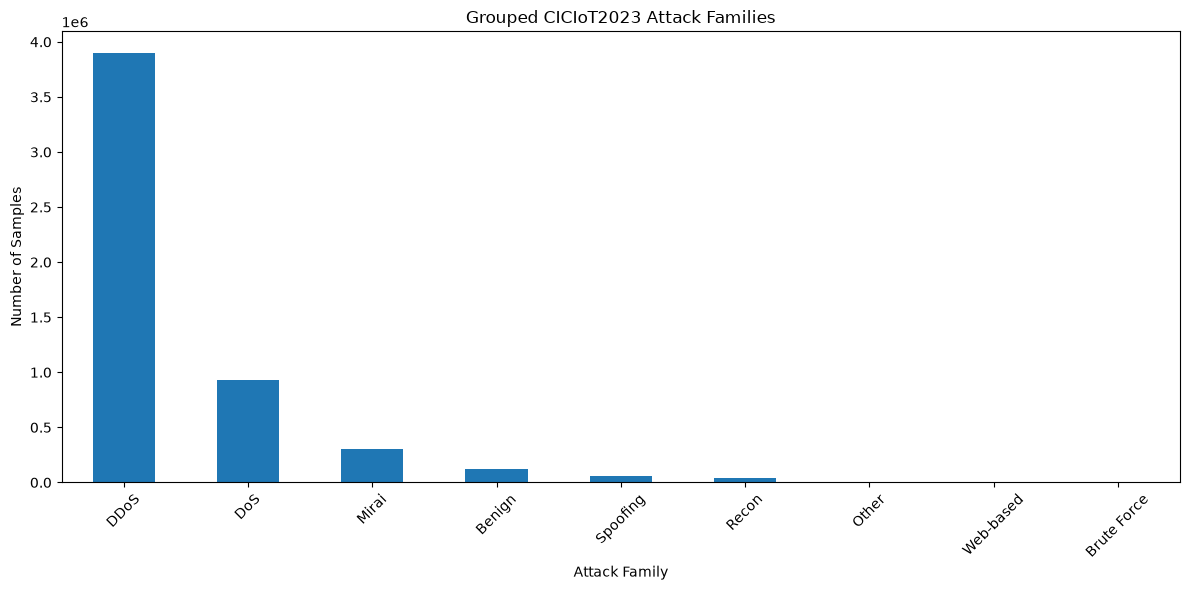

In [58]:
# ------------------------------------------------------------
# GROUPED PLOT
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

grouped_counts.plot(kind="bar")

plt.title("Grouped CICIoT2023 Attack Families")
plt.xlabel("Attack Family")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [59]:
# ------------------------------------------------------------
# COMPARISON
# ------------------------------------------------------------

print(
    "\nFine-grained number of classes:",
    train_df[target_col].nunique()
)

print(
    "Grouped number of classes:",
    train_df["attack_family"].nunique()
)

print("\nGrouped labels:")

for label in sorted(train_df["attack_family"].unique()):
    print("-", label)





Fine-grained number of classes: 34
Grouped number of classes: 9

Grouped labels:
- Benign
- Brute Force
- DDoS
- DoS
- Mirai
- Other
- Recon
- Spoofing
- Web-based


In [60]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("EDA COMPLETED")
print("=" * 70)

print("\nTarget column:", target_col)

print(
    "Fine-grained classes:",
    train_df[target_col].nunique()
)

print(
    "Grouped classes:",
    train_df["attack_family"].nunique()
)

print("\nTraining samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

print("\nAll EDA requirements have been covered.")



EDA COMPLETED

Target column: label
Fine-grained classes: 34
Grouped classes: 9

Training samples: 5357406
Validation samples: 1170554
Testing samples: 1170467

All EDA requirements have been covered.
